# Grover’s Algorithm Exploration

This notebook demonstrates:
- Success probabilities for different target sums \(T\)
- Classical vs. quantum oracle calls comparison
- Scaling advantage as you vary number of qubits \(n\)
- Decoding measurement outcomes for a chosen \(T\)


## Explanation of Edge Cases and Quantum Advantage

**Why do A and B match at edge sums?**
- For \(n=5\), \(a,b\in[0,31]\). Only \((0,0)\) sums to \(T=0\) and only \((31,31)\) sums to \(T=62\), hence 100% success spikes.

**Why is \(T=31\) the fewest oracle calls point?**
- Number of solutions \(M(T)\) peaks at \(T=2^n-1\), giving min classical \(N/M\) and min quantum \(R\approx\frac\pi4\sqrt{N/M}\).

**Scaling advantage**
- Classical: \(O(N/M)\) vs. Quantum: \(O(\sqrt{N/M})\)
- More qubits → classical cost doubles, quantum cost grows by \(\sqrt2\).


In [1]:
import math
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import numpy as np

def count_solutions(n, T):
    if T < 0 or T > 2 * (2**n - 1): return 0
    return min(T + 1, 2**(n+1) - T - 1) if T < 2**n else max(0, 2**(n+1) - T - 1)

def create_oracle(n, T):
    qc = QuantumCircuit(2*n + 1, name=f"Oracle_T{T}")
    a_qubits = list(range(n)); b_qubits = list(range(n, 2*n)); ancilla = 2*n
    for a in range(2**n):
        b = T - a
        if 0 <= b < 2**n:
            a_str = format(a, f'0{n}b')[::-1]
            b_str = format(b, f'0{n}b')[::-1]
            for i, bit in enumerate(a_str):
                if bit == '0': qc.x(i)
            for i, bit in enumerate(b_str):
                if bit == '0': qc.x(i + n)
            qc.mcx(a_qubits + b_qubits, ancilla)
            for i, bit in enumerate(a_str):
                if bit == '0': qc.x(i)
            for i, bit in enumerate(b_str):
                if bit == '0': qc.x(i + n)
    return qc

def build_grover_circuit(n, oracle, iterations):
    num_qubits = 2*n + 1
    qc = QuantumCircuit(num_qubits, 2*n)
    qc.h(range(2*n))
    qc.x(num_qubits-1); qc.h(num_qubits-1)
    for _ in range(iterations):
        qc.append(oracle, range(num_qubits))
        qc.h(range(2*n)); qc.x(range(2*n))
        qc.h(2*n-1); qc.mcx(list(range(2*n-1)), 2*n-1); qc.h(2*n-1)
        qc.x(range(2*n)); qc.h(range(2*n))
    qc.measure(range(2*n), range(2*n))
    return qc

def run_single_n(n=5, shots=500, show_decode_T=None):
    data = []
    sim = AerSimulator()
    for T in range(2**(n+1)-1+1):
        M = count_solutions(n, T)
        if M == 0: continue
        N = 2**(2*n)
        R = max(1, math.floor((math.pi/4) * math.sqrt(N / M)))
        oracle = create_oracle(n, T)
        qc = build_grover_circuit(n, oracle, R)
        result = sim.run(transpile(qc, sim), shots=shots).result().get_counts()
        succ = sum(cnt for bs,cnt in result.items() if int(bs[:n][::-1],2)+int(bs[n:][::-1],2)==T)
        data.append((T, M, R, succ/shots, N/M, result if T==show_decode_T else None))
    Ts, _, Rs, rates, classical_calls, dec = zip(*data)
    plt.figure(figsize=(12,8))
    plt.subplot(2,1,1)
    plt.plot(Ts, rates, 'o-'); plt.axvline(2**n-1, color='r', linestyle='--')
    plt.title(f'Grover Performance (n={n})'); plt.xlabel('T'); plt.ylabel('Success Prob'); plt.grid()
    plt.subplot(2,1,2)
    plt.plot(Ts, classical_calls, 'g-', label='Classical N/M')
    plt.plot(Ts, Rs, 'r-', label='Quantum R'); plt.yscale('log')
    plt.title('Oracle Calls vs T'); plt.xlabel('T'); plt.ylabel('Calls'); plt.grid(); plt.legend()
    plt.tight_layout(); plt.show()
    peak = max(data, key=lambda x: x[3])
    print(f"Peak success {peak[3]:.2f} at T={peak[0]}, M={peak[1]}, R={peak[2]}")
    if show_decode_T is not None:
        print(f"\nDecoded results for T={show_decode_T}:")
        for bs,cnt in dec.items():
            a=int(bs[:n][::-1],2); b=int(bs[n:][::-1],2)
            print(f"{bs} → a={a}, b={b} [{cnt}]")

def plot_scaling(ns=[4,5,6,7]):
    ks = np.array(ns)
    Ns = 2**(2*ks)
    classical = Ns/2
    quantum = (math.pi/4)*np.sqrt(Ns)
    plt.loglog(Ns, classical, 'o-', label='Classical N/2')
    plt.loglog(Ns, quantum, 's-', label='Quantum π/4√N')
    for n_val, N in zip(ns, Ns): plt.annotate(f"n={n_val}", (N, (math.pi/4)*math.sqrt(N)))
    plt.xlabel('Search space N'); plt.ylabel('Oracle Calls'); plt.title('Scaling vs n'); plt.grid(); plt.legend(); plt.show()


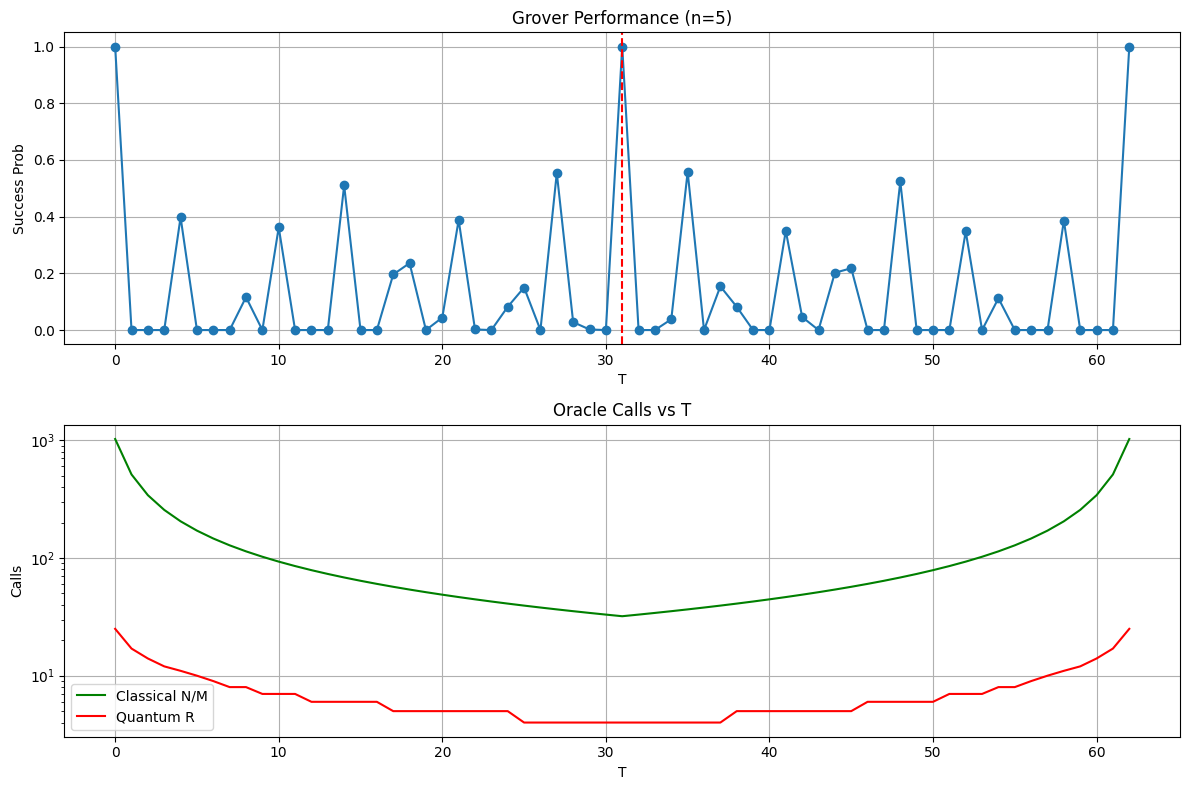

Peak success 1.00 at T=0, M=1, R=25

Decoded results for T=31:


AttributeError: 'tuple' object has no attribute 'items'

In [2]:
# Usage
run_single_n(n=5, shots=500, show_decode_T=31)
plot_scaling([4,5,6,7])